# agentv14_subgraphs — Reusable Specialist Graphs

This version introduces subgraphs.

Parent graph:

```text
START → supervisor → sql_subgraph → rag_subgraph → final_synthesis → END
```

SQL subgraph:

```text
START → sql_plan → sql_execute → sql_summary → END
```

RAG subgraph:

```text
START → rag_retrieve → rag_summary → END
```


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state using NotRequired

From v14 onward, we use `NotRequired` instead of `total=False`.

This makes required and optional fields explicit.


In [3]:
from typing import NotRequired, TypedDict

class ParentState(TypedDict):
    input: str
    route_note: NotRequired[str]
    sql_plan: NotRequired[str]
    sql_result: NotRequired[str]
    sql_summary: NotRequired[str]
    rag_context: NotRequired[str]
    rag_summary: NotRequired[str]
    final_answer: NotRequired[str]

class SqlState(TypedDict):
    input: str
    sql_plan: NotRequired[str]
    sql_result: NotRequired[str]
    sql_summary: NotRequired[str]

class RagState(TypedDict):
    input: str
    rag_context: NotRequired[str]
    rag_summary: NotRequired[str]


## 4. Supervisor node


In [4]:
def supervisor_node(state: ParentState) -> ParentState:
    return {
        "route_note": "Supervisor selected SQL and RAG subgraphs for metrics plus document evidence."
    }


## 5. Build SQL subgraph


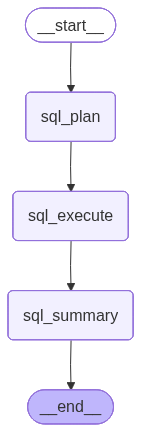

In [5]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph

def sql_plan_node(state: SqlState) -> SqlState:
    return {
        "sql_plan": (
            "Plan: query failure volume and average response_time for CHECK-DOMAIN "
            "during and after release R13."
        )
    }

def sql_execute_node(state: SqlState) -> SqlState:
    return {
        "sql_result": (
            "SQL result: CHECK-DOMAIN CONNECTION_TIMEOUT volume increased after R13; "
            "average response_time exceeded 220 ms during peak windows."
        )
    }

def sql_summary_node(state: SqlState) -> SqlState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
Summarize this SQL analysis for an EPP SLA incident.

User request:
{state["input"]}

SQL plan:
{state["sql_plan"]}

SQL result:
{state["sql_result"]}
'''

    response = llm.invoke(prompt)
    return {"sql_summary": response.content}

def build_sql_subgraph():
    graph_builder = StateGraph(SqlState)

    graph_builder.add_node("sql_plan", sql_plan_node)
    graph_builder.add_node("sql_execute", sql_execute_node)
    graph_builder.add_node("sql_summary", sql_summary_node)

    graph_builder.add_edge(START, "sql_plan")
    graph_builder.add_edge("sql_plan", "sql_execute")
    graph_builder.add_edge("sql_execute", "sql_summary")
    graph_builder.add_edge("sql_summary", END)

    return graph_builder.compile()

sql_subgraph = build_sql_subgraph()
sql_subgraph


## 6. Build RAG subgraph


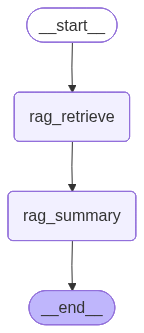

In [6]:
def rag_retrieve_node(state: RagState) -> RagState:
    return {
        "rag_context": (
            "Retrieved docs: R13 release notes mention connection pool changes and a known "
            "CHECK-DOMAIN latency risk under saturation. Runbook recommends registry endpoint, "
            "DNS resolver, and upstream connectivity checks."
        )
    }

def rag_summary_node(state: RagState) -> RagState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
Summarize this retrieved document context for an EPP SLA incident.

User request:
{state["input"]}

Retrieved context:
{state["rag_context"]}
'''

    response = llm.invoke(prompt)
    return {"rag_summary": response.content}

def build_rag_subgraph():
    graph_builder = StateGraph(RagState)

    graph_builder.add_node("rag_retrieve", rag_retrieve_node)
    graph_builder.add_node("rag_summary", rag_summary_node)

    graph_builder.add_edge(START, "rag_retrieve")
    graph_builder.add_edge("rag_retrieve", "rag_summary")
    graph_builder.add_edge("rag_summary", END)

    return graph_builder.compile()

rag_subgraph = build_rag_subgraph()
rag_subgraph


## 7. Final synthesis node


In [7]:
def final_synthesis_node(state: ParentState) -> ParentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
User request:
{state["input"]}

Supervisor note:
{state.get("route_note", "")}

SQL summary:
{state.get("sql_summary", "")}

RAG summary:
{state.get("rag_summary", "")}

Write a concise final incident analysis with:
1. likely cause
2. supporting evidence
3. recommended next action
'''

    response = llm.invoke(prompt)
    return {"final_answer": response.content}


## 8. Build parent graph

The compiled subgraphs are added as nodes.


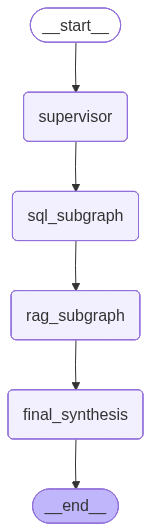

In [8]:
def build_parent_graph():
    sql_subgraph = build_sql_subgraph()
    rag_subgraph = build_rag_subgraph()

    graph_builder = StateGraph(ParentState)

    graph_builder.add_node("supervisor", supervisor_node)
    graph_builder.add_node("sql_subgraph", sql_subgraph)
    graph_builder.add_node("rag_subgraph", rag_subgraph)
    graph_builder.add_node("final_synthesis", final_synthesis_node)

    graph_builder.add_edge(START, "supervisor")
    graph_builder.add_edge("supervisor", "sql_subgraph")
    graph_builder.add_edge("sql_subgraph", "rag_subgraph")
    graph_builder.add_edge("rag_subgraph", "final_synthesis")
    graph_builder.add_edge("final_synthesis", END)

    return graph_builder.compile()

parent_graph = build_parent_graph()
parent_graph


## 9. Visualize parent graph


In [9]:
print(parent_graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	sql_subgraph(sql_subgraph)
	rag_subgraph(rag_subgraph)
	final_synthesis(final_synthesis)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	rag_subgraph --> final_synthesis;
	sql_subgraph --> rag_subgraph;
	supervisor --> sql_subgraph;
	final_synthesis --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 10. Visualize parent graph PNG


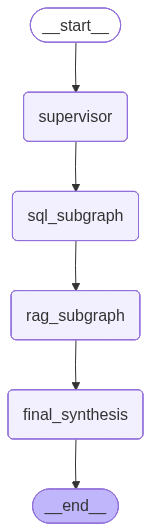

In [10]:
from IPython.display import Image, display

try:
    display(Image(parent_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 11. Visualize SQL subgraph


In [11]:
print(sql_subgraph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	sql_plan(sql_plan)
	sql_execute(sql_execute)
	sql_summary(sql_summary)
	__end__([<p>__end__</p>]):::last
	__start__ --> sql_plan;
	sql_execute --> sql_summary;
	sql_plan --> sql_execute;
	sql_summary --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 12. Visualize RAG subgraph


In [12]:
print(rag_subgraph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	rag_retrieve(rag_retrieve)
	rag_summary(rag_summary)
	__end__([<p>__end__</p>]):::last
	__start__ --> rag_retrieve;
	rag_retrieve --> rag_summary;
	rag_summary --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 13. Run parent graph


In [13]:
result = parent_graph.invoke({
    "input": "Investigate CHECK-DOMAIN timeout risk after R13 using SQL and docs."
})

print(result["final_answer"])


### Final Incident Analysis: CHECK-DOMAIN Timeout Risk Post R13

**1. Likely Cause:**
The increase in CHECK-DOMAIN CONNECTION_TIMEOUT incidents following release R13 is likely due to changes made to the connection pool, which have introduced a known latency risk when the system is under saturation. This alteration has resulted in longer average response times, particularly during peak usage periods.

**2. Supporting Evidence:**
- **SQL Analysis:** Post-R13, there was a notable increase in CHECK-DOMAIN CONNECTION_TIMEOUT incidents, with average response times exceeding 220 milliseconds during peak periods. This indicates a direct correlation between the release and the observed timeout issues.
- **RAG Context:** The R13 release notes explicitly mention modifications to the connection pool and highlight a known latency risk for CHECK-DOMAIN operations under high load. The runbook also recommends checks on the registry endpoint, DNS resolver, and upstream connectivity, further supporting 

## 14. Inspect state from subgraphs


In [14]:
print("SQL plan:", result.get("sql_plan"))
print()
print("SQL result:", result.get("sql_result"))
print()
print("SQL summary:", result.get("sql_summary"))
print()
print("RAG context:", result.get("rag_context"))
print()
print("RAG summary:", result.get("rag_summary"))


SQL plan: Plan: query failure volume and average response_time for CHECK-DOMAIN during and after release R13.

SQL result: SQL result: CHECK-DOMAIN CONNECTION_TIMEOUT volume increased after R13; average response_time exceeded 220 ms during peak windows.

SQL summary: The SQL analysis for the EPP SLA incident focused on investigating the timeout risk associated with the CHECK-DOMAIN function following release R13. The plan involved querying the failure volume and average response time for CHECK-DOMAIN both during and after the release.

The results indicated that the volume of CHECK-DOMAIN CONNECTION_TIMEOUT incidents increased after R13, and the average response time during peak periods exceeded 220 milliseconds. This suggests a heightened risk of timeouts for CHECK-DOMAIN operations post-release.

RAG context: Retrieved docs: R13 release notes mention connection pool changes and a known CHECK-DOMAIN latency risk under saturation. Runbook recommends registry endpoint, DNS resolver, and

## 15. Why this matters

Subgraphs let each specialist become a real workflow.

This is better than keeping every specialist as one large function.

Production architecture often looks like:

```text
Parent Supervisor Graph
  ├── SQL Specialist Subgraph
  ├── RAG Specialist Subgraph
  ├── CloudOps Specialist Subgraph
  └── Final Synthesis
```


## 16. LangSmith trace

Open project:

```text
langgraph-playground
```

Look for nested traces under the parent graph.
